In [1]:
import sys
from pathlib import Path
sys.path.insert(0, str(Path("..").resolve()))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import logging

# Show logs in the notebook output
logging.basicConfig(level=logging.INFO,
                    format="%(levelname)s | %(name)s | %(message)s")

from src.config import cfg
from src.data.loader import load_raw
from src.data.cleaner import clean, replace_sentinels, COLUMN_RENAME

print("✅ Imports ready")

✅ Imports ready


In [2]:
# Load the raw data exactly as it came from disk
df_raw = load_raw()
print(f"Raw shape:   {df_raw.shape}")
print(f"Raw dtypes sample:\n{df_raw.dtypes.head(5)}\n")

# Run the full pipeline — watch the logs
df_clean = clean(df_raw)
print(f"\nClean shape: {df_clean.shape}")

INFO | src.data.loader | Loading raw data from: C:\Users\CDAC\Documents\AI\weather\data\raw\weather.csv
INFO | src.data.loader | Successfully loaded 52,696 rows × 21 columns.
INFO | src.data.cleaner | ========================================
INFO | src.data.cleaner | Starting cleaning pipeline
INFO | src.data.cleaner | Input:  52,696 rows × 21 columns
INFO | src.data.cleaner | Replacing sentinel (-9999.0) in 3 columns:
INFO | src.data.cleaner |   wv (m/s): 1 values
INFO | src.data.cleaner |   max. PAR (�mol/m�/s): 30 values
INFO | src.data.cleaner |   OT: 50 values
INFO | src.data.cleaner | Interpolated 43 values (38 NaN remain after limit)
INFO | src.data.cleaner | Renamed 21 columns
INFO | src.data.cleaner | Resampled 52,696 → 8,785 rows (freq=1h, reduction=6.0x)
INFO | src.data.cleaner | Validation passed — all columns within physical limits
INFO | src.data.cleaner | Output: 8,785 rows × 21 columns
INFO | src.data.cleaner | Cleaning pipeline complete
INFO | src.data.cleaner | ======

Raw shape:   (52696, 21)
Raw dtypes sample:
p (mbar)       float64
T (degC)       float64
Tpot (K)       float64
Tdew (degC)    float64
rh (%)         float64
dtype: object


Clean shape: (8785, 21)


In [3]:
print(f"Clean columns (first 8): {df_clean.columns[:8].tolist()}")

Clean columns (first 8): ['pressure_mbar', 'temp_c', 'temp_potential_k', 'dew_point_c', 'humidity_pct', 'vapor_pressure_max', 'vapor_pressure_act', 'vapor_pressure_def']


In [4]:
# Check for any remaining sentinel values in the clean data
remaining_sentinels = (df_clean == cfg.sentinel_value).sum().sum()
remaining_nans = df_clean.isna().sum().sum()

print(f"Sentinel -9999 values remaining : {remaining_sentinels}")
print(f"NaN values remaining            : {remaining_nans}")
print(f"\nNaN by column (if any):")
nan_cols = df_clean.isna().sum()
print(nan_cols[nan_cols > 0] if nan_cols.sum() > 0 else "  None — all gaps filled ✅")

Sentinel -9999 values remaining : 0
NaN values remaining            : 26

NaN by column (if any):
pressure_mbar         1
temp_c                1
temp_potential_k      1
dew_point_c           1
humidity_pct          1
vapor_pressure_max    1
vapor_pressure_act    1
vapor_pressure_def    1
specific_humidity     1
h2o_concentration     1
air_density           1
wind_speed            1
wind_speed_max        1
wind_direction        1
rain_mm               1
raining_s             1
solar_radiation       1
par                   1
par_max               1
temp_logged           1
output_temp           6
dtype: int64


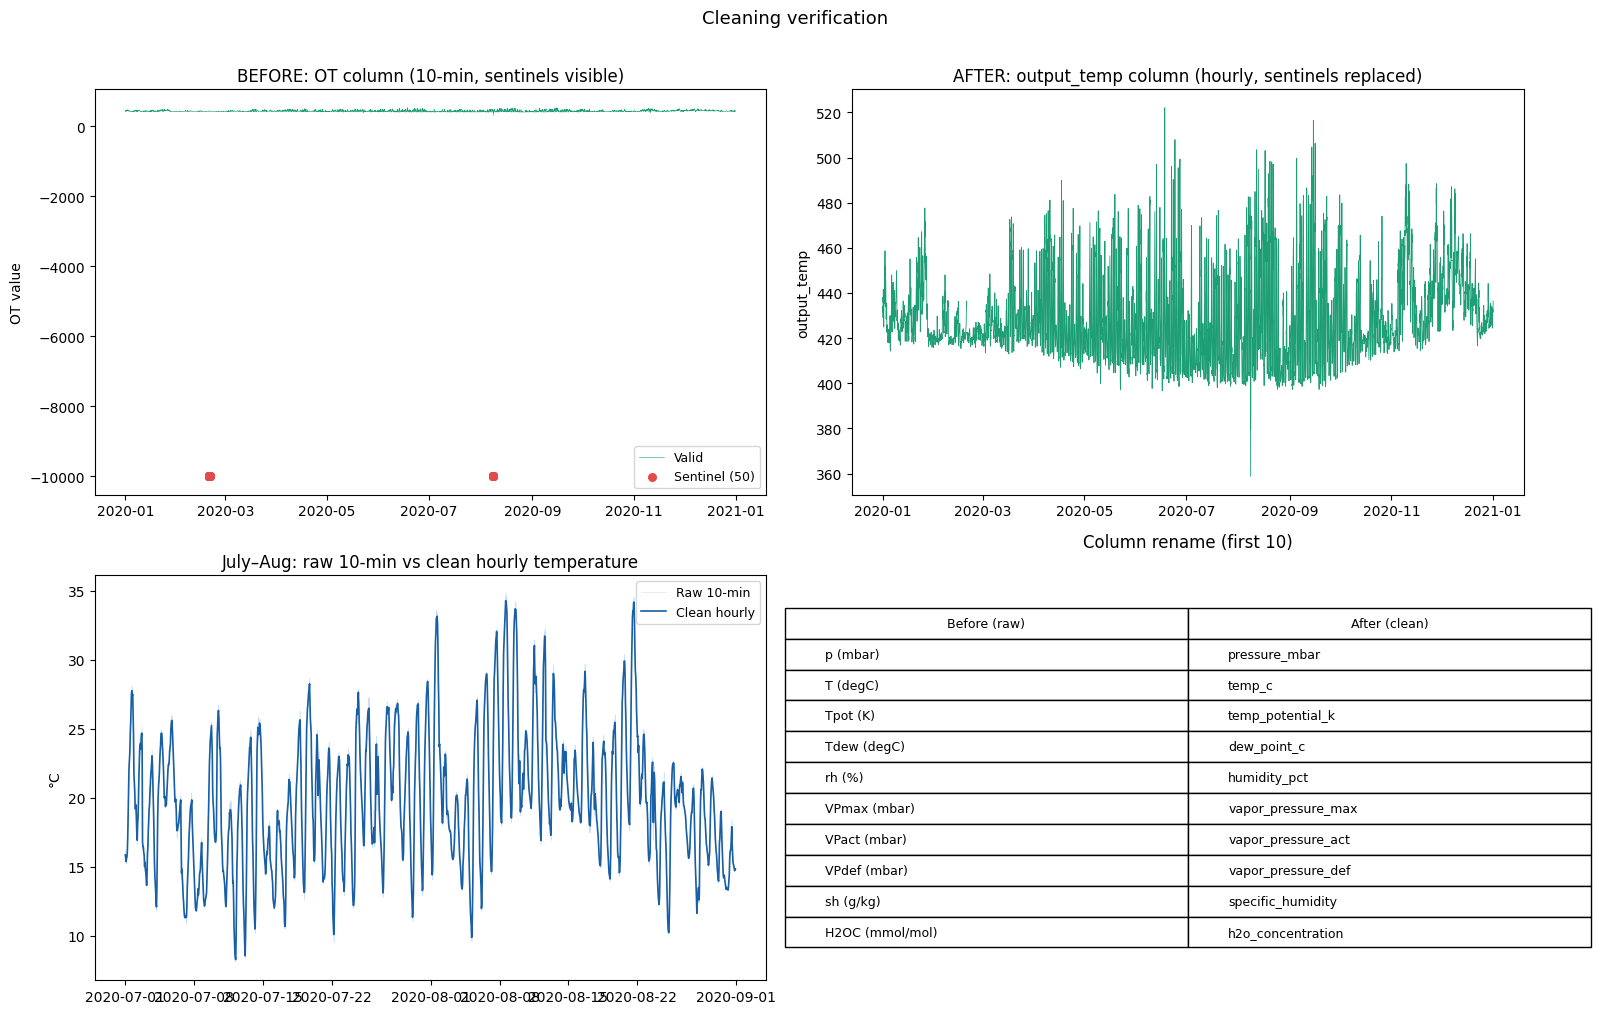

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# ── Top left: OT column raw (with sentinels visible) ──────────────────────
ax = axes[0, 0]
raw_ot = df_raw["OT"].replace(cfg.sentinel_value, np.nan)
sentinel_mask = df_raw["OT"] == cfg.sentinel_value
ax.plot(df_raw.index, raw_ot, lw=0.4, color="#1D9E75", label="Valid")
ax.scatter(df_raw.index[sentinel_mask], df_raw["OT"][sentinel_mask],
           color="#E24B4A", s=30, zorder=5, label=f"Sentinel ({sentinel_mask.sum()})")
ax.set_title("BEFORE: OT column (10-min, sentinels visible)")
ax.legend(fontsize=9)
ax.set_ylabel("OT value")

# ── Top right: output_temp after cleaning ─────────────────────────────────
ax = axes[0, 1]
ax.plot(df_clean.index, df_clean["output_temp"],
        lw=0.6, color="#1D9E75")
ax.set_title("AFTER: output_temp column (hourly, sentinels replaced)")
ax.set_ylabel("output_temp")

# ── Bottom left: temperature raw vs clean overlay ─────────────────────────
ax = axes[1, 0]
# Show one month for clarity
jan_raw   = df_raw["T (degC)"].loc["2020-07":"2020-08"]
jan_clean = df_clean["temp_c"].loc["2020-07":"2020-08"]
ax.plot(jan_raw.index,   jan_raw.values,   lw=0.4, color="#B5D4F4",
        label="Raw 10-min", alpha=0.7)
ax.plot(jan_clean.index, jan_clean.values, lw=1.2, color="#185FA5",
        label="Clean hourly")
ax.set_title("July–Aug: raw 10-min vs clean hourly temperature")
ax.set_ylabel("°C")
ax.legend(fontsize=9)

# ── Bottom right: column names before/after ───────────────────────────────
ax = axes[1, 1]
ax.axis("off")
before = list(df_raw.columns[:10])
after  = list(df_clean.columns[:10])
table_data = list(zip(before, after))
tbl = ax.table(
    cellText=table_data,
    colLabels=["Before (raw)", "After (clean)"],
    loc="center", cellLoc="left"
)
tbl.auto_set_font_size(False)
tbl.set_fontsize(9)
tbl.scale(1.2, 1.6)
ax.set_title("Column rename (first 10)", pad=20)

plt.suptitle("Cleaning verification", fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [ ]:
# Save to parquet — this is the input to Phase 4
output_path = cfg.processed_data_path
output_path.parent.mkdir(parents=True, exist_ok=True)

df_clean.to_parquet(output_path)

# Verify it round-trips correctly
df_verify = pd.read_parquet(output_path)
assert df_verify.shape == df_clean.shape, "Round-trip shape mismatch!"
assert list(df_verify.columns) == list(df_clean.columns), "Column mismatch!"

print(f"✅ Saved to: {output_path}")
print(f"   Shape: {df_clean.shape}")
print(f"   Size on disk: {output_path.stat().st_size / 1024:.1f} KB")
print(f"   (Compare to raw CSV: {cfg.raw_data_path.stat().st_size / 1024:.1f} KB)")